In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspect
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import tree

# Configuración visual
plt.style.use("default")
sns.set_theme(style="whitegrid")

# Semilla para reproducibilidad
np.random.seed(42)

In [2]:
url_SocialMediaP = "https://raw.githubusercontent.com/Merenguimona/act2IA/refs/heads/main/Datasets/social_media_productivity_6000.csv"

dt_SocialMediaP = pd.read_csv(url_SocialMediaP, sep= ",")

print("Primeras filas")
dt_SocialMediaP.head()

Primeras filas


,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09


In [3]:
dt_SocialMediaP.describe(include="all")

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
count,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880,5880.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3064,NaN
mean,27.111395,6.923175,4.145915,4.069328,6.514270,159.781463,96.363531,NaN,37.614051
std,7.268430,2.859055,2.155496,2.309472,1.434351,81.044666,7.416839,NaN,27.603251
min,15.000000,2.000000,0.660000,0.000000,4.000000,20.000000,47.390000,NaN,0.000000
25%,21.000000,4.470000,2.400000,2.120000,5.270000,89.000000,96.360000,NaN,13.565000
50%,27.000000,6.860000,3.755000,4.115000,6.525000,160.000000,100.000000,NaN,36.200000
75%,33.000000,9.360000,5.540000,6.030000,7.730000,231.000000,100.000000,NaN,58.560000


In [4]:
print("Dimensiones:", dt_SocialMediaP.shape)

print("\nInformación general")
dt_SocialMediaP.info()

print("\nTipos de datos")
print(dt_SocialMediaP.dtypes)

Dimensiones: (6000, 9)

Información general
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   str    
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), str(1)
memory usage: 422.0 KB

Tipos de datos
age                      float64
daily_screen_time        float64
social_media_hours       float64
study_hours              float64
sleep_hours              float64
notifications_per_day    float64
focus_score              

In [5]:
print("Valores nulos por columna")
print(dt_SocialMediaP.isnull().sum())

print("\nDuplicados:", dt_SocialMediaP.duplicated().sum())

Valores nulos por columna
age                      120
daily_screen_time        120
social_media_hours       120
study_hours              120
sleep_hours              120
notifications_per_day    120
focus_score              120
addiction_level          120
productivity_score       120
dtype: int64

Duplicados: 0


In [6]:
#Eliminando nulls del dataset.

# Rellenar con la media Valores numericos(float)
dt_SocialMediaP = dt_SocialMediaP.fillna(dt_SocialMediaP.mean(numeric_only=True))

#Rellenar con la moda el addition_level(str)
dt_SocialMediaP["addiction_level"] = dt_SocialMediaP["addiction_level"].fillna(
    dt_SocialMediaP["addiction_level"].mode()[0]
)

print("\nNulos después:")
print(dt_SocialMediaP.isnull().sum())

print("\nTamaño final:")
print(dt_SocialMediaP.shape)


Nulos después:
age                      0
daily_screen_time        0
social_media_hours       0
study_hours              0
sleep_hours              0
notifications_per_day    0
focus_score              0
addiction_level          0
productivity_score       0
dtype: int64

Tamaño final:
(6000, 9)


In [7]:
#Transformar todo a numerico para mejor análisis.
le = LabelEncoder()
jerarquia = {"Low": 0, "Medium": 1, "High": 2}

# CAMBIO AQUÍ: Usamos una lista para incluir "object" y "str" explícitamente
for col in dt_SocialMediaP.select_dtypes(include=["object", "str"]).columns:
    if col == "addiction_level":
        dt_SocialMediaP[col] = dt_SocialMediaP[col].map(jerarquia)
    else:
        dt_SocialMediaP[col] = le.fit_transform(dt_SocialMediaP[col])

dt_SocialMediaP.info()
#Valores del addiction_level
dt_SocialMediaP['addiction_level'].unique()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    6000 non-null   float64
 1   daily_screen_time      6000 non-null   float64
 2   social_media_hours     6000 non-null   float64
 3   study_hours            6000 non-null   float64
 4   sleep_hours            6000 non-null   float64
 5   notifications_per_day  6000 non-null   float64
 6   focus_score            6000 non-null   float64
 7   addiction_level        6000 non-null   int64  
 8   productivity_score     6000 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 422.0 KB


array([1, 0, 2], dtype=int64)

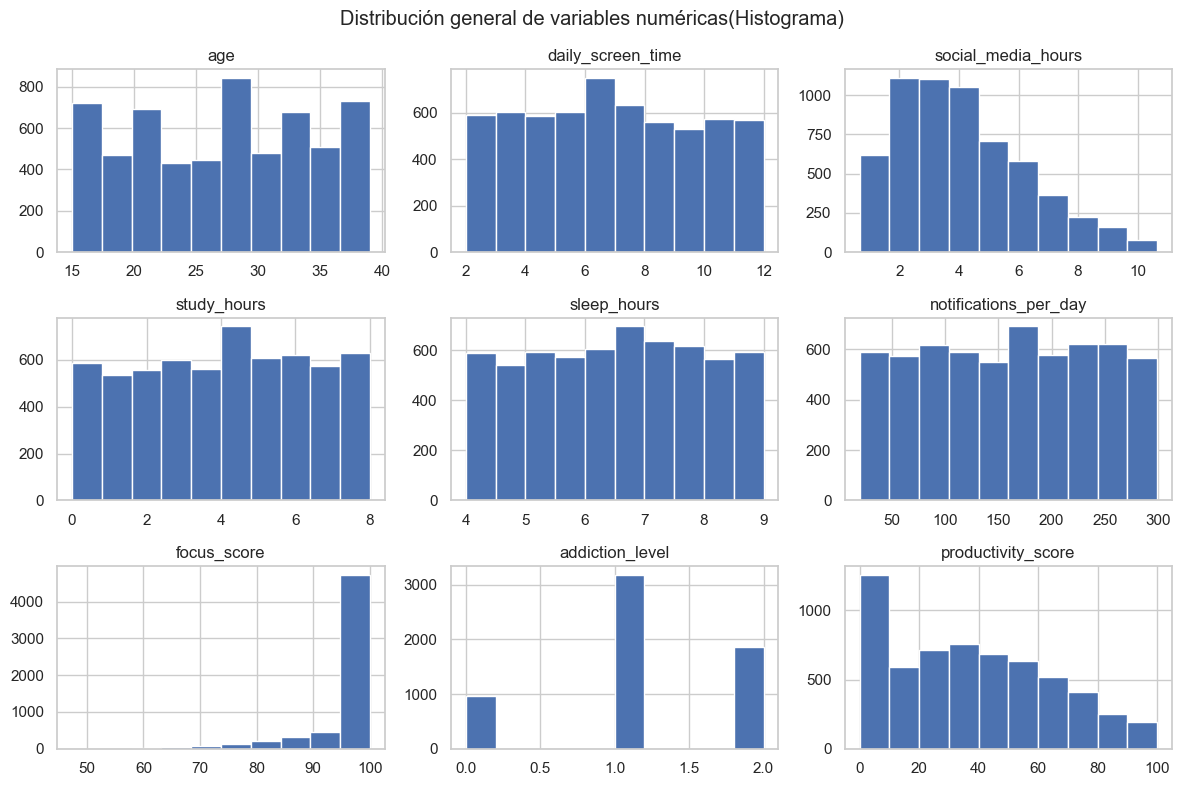

In [8]:
#Histograma
dt_SocialMediaP.hist(figsize=(12,8))
plt.suptitle("Distribución general de variables numéricas(Histograma)")
plt.tight_layout()
plt.show()

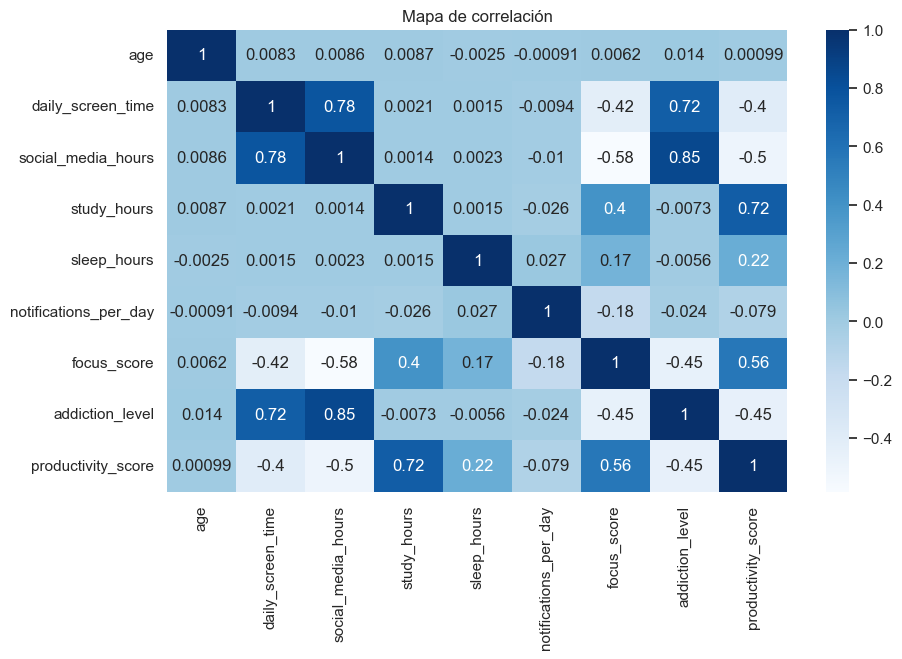

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(
    dt_SocialMediaP.corr(numeric_only=True),
    annot=True,
    cmap="Blues"
)
plt.title("Mapa de correlación")
plt.show()

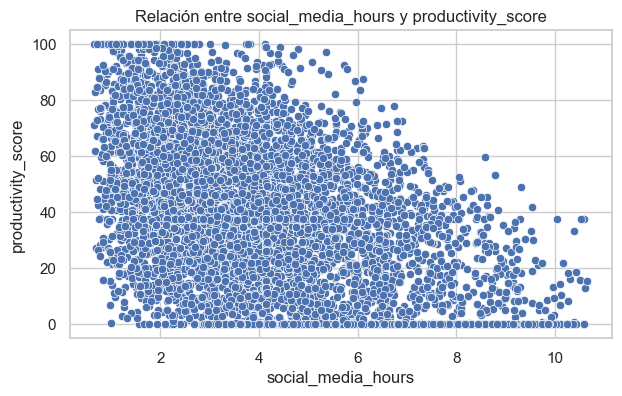

In [10]:
plt.figure(figsize=(7,4))

sns.scatterplot(
    data=dt_SocialMediaP,
    x="social_media_hours",
    y="productivity_score"
)

plt.title("Relación entre social_media_hours y productivity_score")
plt.show()

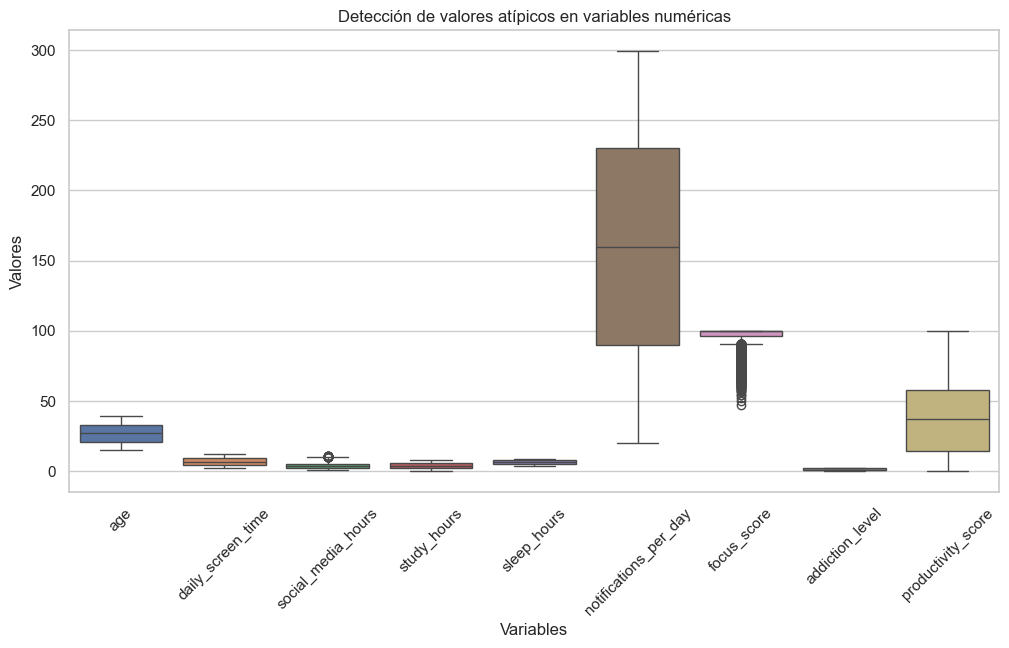

In [11]:
plt.figure(figsize=(12,6))

sns.boxplot(data=dt_SocialMediaP.select_dtypes(include="number"))

plt.xticks(rotation=45)
plt.title("Detección de valores atípicos en variables numéricas")
plt.xlabel("Variables")
plt.ylabel("Valores")

plt.show()

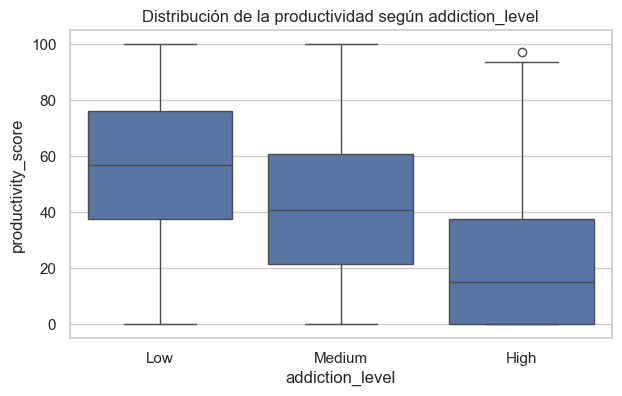

In [12]:
mapa_adiccion = {0: "Low", 1: "Medium", 2: "High"}

dt_SocialMediaP["addiction_level"] = dt_SocialMediaP["addiction_level"].map(mapa_adiccion)

plt.figure(figsize=(7,4))

sns.boxplot(
    data=dt_SocialMediaP,
    x="addiction_level",
    y="productivity_score",
    order=["Low", "Medium", "High"]
)

plt.title("Distribución de la productividad según addiction_level")
plt.show()

## Hallazgos EDA


Durante el análisis exploratorio preliminar se logran observar 2 variables objetivo **productivity_score** y **addiction_level** siendo estas las de mayor relevancia para el conjunto de datos analizado. De igual manera se observó que las variables numéricas presentan distribuciones relativamente estables, con una mayor concentración de registros en rangos medios de *productivity_score* y *focus_score*, lo que sugiere un comportamiento general consistente en los niveles de productividad y enfoque de los usuarios.

El mapa de correlación evidenció una relación negativa entre *social_media_hours* y *productivity_score*, indicando que, a medida que aumentan las horas dedicadas a redes sociales, la productividad tiende a disminuir. De manera complementaria, la variable *sleep_hours* mostró una asociación positiva con *focus_score*, sugiriendo que mayores horas de descanso se relacionan con mejores niveles de concentración.

Finalmente, el gráfico de distribución de la productividad según *addiction_level* permitió identificar que los usuarios con un nivel de adicción alto (High) presentan medianas de productividad más bajas, reforzando la hipótesis de que un mayor grado de dependencia al uso de redes sociales impacta negativamente en el desempeño de las actividades diarias.

# Modelo de Redes Neuronales para Clasificación de Nivel de Adicción

En esta sección, implementaremos un modelo de red neuronal para clasificar el nivel de adicción a las redes sociales (addiction_level) utilizando los datos del dataset de Social Media Productivity. Basándonos en el EDA realizado previamente, utilizaremos las características numéricas escaladas.

El modelo consistirá en:
- Una capa de entrada
- Dos capas ocultas (intermedias) con funciones de activación ReLU y dropout
- Una capa de salida con activación softmax para clasificación multiclase

Utilizaremos TensorFlow/Keras para construir y entrenar el modelo.

In [21]:
# Preparación de datos para el modelo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar características (X) y variable objetivo (y)
X = dt_SocialMediaP.drop(columns=['addiction_level'])
y = dt_SocialMediaP['addiction_level']

# Escalar las características numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Dimensiones del conjunto de entrenamiento:", X_train.shape)
print("Dimensiones del conjunto de prueba:", X_test.shape)
print("Distribución de clases en y_train:", y_train.value_counts())
print("Distribución de clases en y_test:", y_test.value_counts())

Dimensiones del conjunto de entrenamiento: (4800, 8)
Dimensiones del conjunto de prueba: (1200, 8)
Distribución de clases en y_train: addiction_level
Medium    2547
High      1486
Low        767
Name: count, dtype: int64
Distribución de clases en y_test: addiction_level
Medium    637
High      371
Low       192
Name: count, dtype: int64


In [28]:
# Recodificar la variable objetivo a enteros para la red neuronal
y_int = y.map({"Low": 0, "Medium": 1, "High": 2})

# Dividir en conjuntos de entrenamiento y prueba con y_int
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_int, test_size=0.2, random_state=42, stratify=y_int)

print("y_train tipo:", type(y_train.iloc[0]))
print("Valores únicos en y_train:", y_train.unique())

y_train tipo: <class 'numpy.int64'>
Valores únicos en y_train: [1 2 0]


In [22]:
# Importar TensorFlow/Keras para el modelo de redes neuronales
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [26]:
# Construcción del modelo de red neuronal
model = Sequential()

# Capa de entrada y primera capa oculta
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dropout(0.2))

# Segunda capa oculta
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# Capa de salida
model.add(Dense(3, activation='softmax'))  # 3 clases: Low, Medium, High

# Compilar el modelo
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Arquitectura del modelo:")
model.summary()

Arquitectura del modelo:


c:\Users\elvla\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,755 (10.76 KB)

 Trainable params: 2,755 (10.76 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Entrenamiento del modelo de red neuronal
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[early_stopping],
                    verbose=1)

print("Entrenamiento completado.")

Epoch 1/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6146 - loss: 0.8639 - val_accuracy: 0.8646 - val_loss: 0.4139
Epoch 2/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8014 - loss: 0.4593 - val_accuracy: 0.8938 - val_loss: 0.3164
Epoch 3/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8393 - loss: 0.3771 - val_accuracy: 0.8896 - val_loss: 0.2794
Epoch 4/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8720 - loss: 0.3462 - val_accuracy: 0.9125 - val_loss: 0.2521
Epoch 5/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8753 - loss: 0.3141 - val_accuracy: 0.9083 - val_loss: 0.2385
Epoch 6/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8842 - loss: 0.2974 - val_accuracy: 0.9260 - val_loss: 0.2198
Epoch 7/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8934 - loss: 0.2797 - val_accuracy: 0.9354 - val_loss: 0.2035
Epoch 8/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9044 - loss: 0.2593 - val_accu

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.9791666666666666

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       192
           1       0.98      0.98      0.98       637
           2       0.99      0.98      0.98       371

    accuracy                           0.98      1200
   macro avg       0.98      0.98      0.98      1200
weighted avg       0.98      0.98      0.98      1200



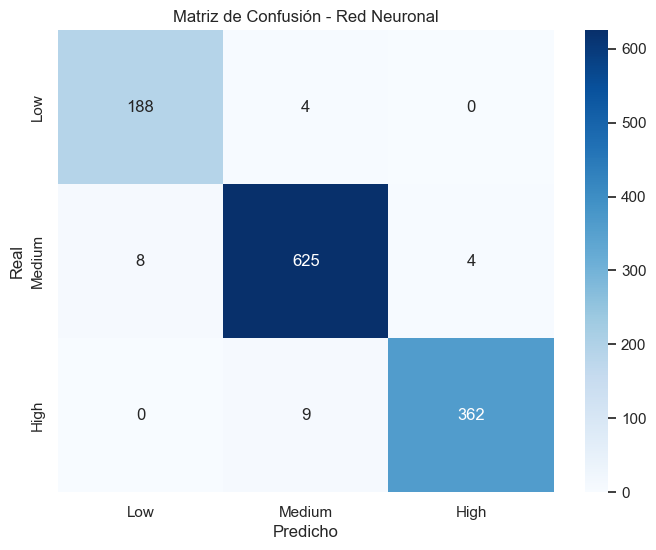

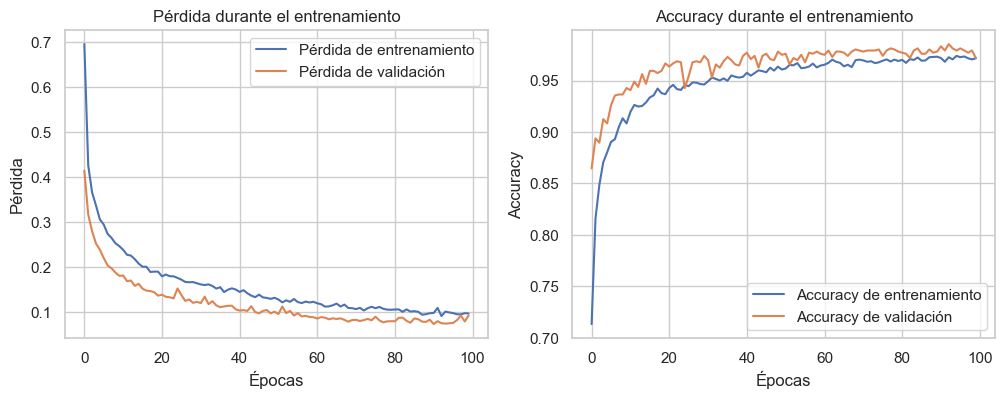

In [30]:
# Evaluación del modelo de red neuronal
# Predicciones en el conjunto de prueba
y_pred_prob = model.predict(X_test)
y_pred = y_pred_prob.argmax(axis=1)

# Métricas de evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
plt.title('Matriz de Confusión - Red Neuronal')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# Gráfico de pérdida y accuracy durante el entrenamiento
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Accuracy de entrenamiento')
plt.plot(history.history['val_accuracy'], label='Accuracy de validación')
plt.title('Accuracy durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [31]:
# Evaluación final en conjunto de prueba
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Pérdida en conjunto de prueba: {test_loss:.4f}")
print(f"Accuracy en conjunto de prueba: {test_accuracy:.4f}")

# Comparación con datos de entrenamiento
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
print(f"Pérdida en conjunto de entrenamiento: {train_loss:.4f}")
print(f"Accuracy en conjunto de entrenamiento: {train_accuracy:.4f}")

Pérdida en conjunto de prueba: 0.0818
Accuracy en conjunto de prueba: 0.9792
Pérdida en conjunto de entrenamiento: 0.0748
Accuracy en conjunto de entrenamiento: 0.9804


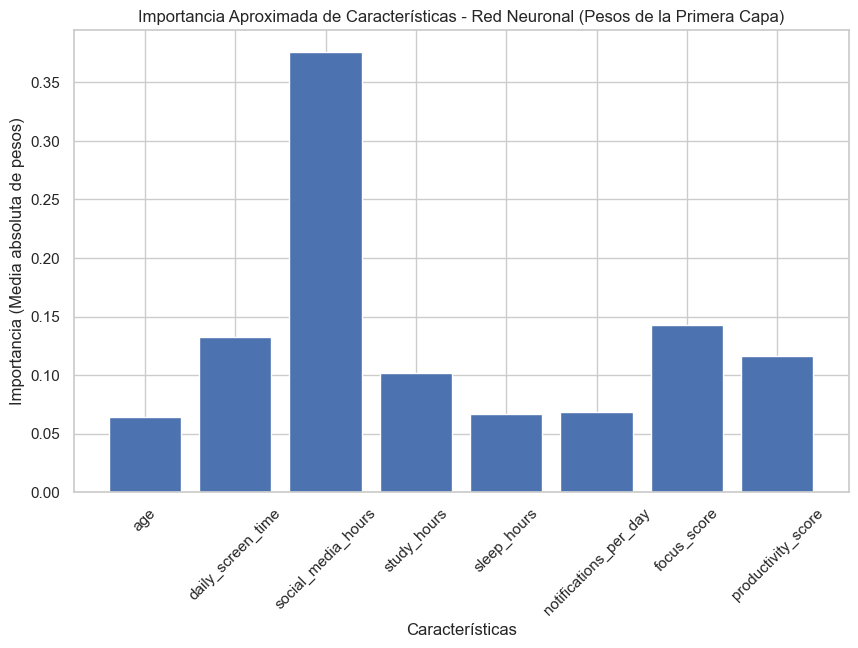

Top 5 características por importancia aproximada:
social_media_hours: 0.3757
focus_score: 0.1431
daily_screen_time: 0.1324
productivity_score: 0.1166
study_hours: 0.1020


In [32]:
# Análisis de pesos de la primera capa (importancia aproximada)
weights, biases = model.layers[0].get_weights()
feature_importance_nn = np.abs(weights).mean(axis=1)  # Media absoluta de pesos por característica

plt.figure(figsize=(10,6))
plt.bar(range(len(feature_importance_nn)), feature_importance_nn)
plt.xticks(range(len(X.columns)), X.columns, rotation=45)
plt.title('Importancia Aproximada de Características - Red Neuronal (Pesos de la Primera Capa)')
plt.xlabel('Características')
plt.ylabel('Importancia (Media absoluta de pesos)')
plt.show()

print("Top 5 características por importancia aproximada:")
top_features = sorted(zip(X.columns, feature_importance_nn), key=lambda x: x[1], reverse=True)[:5]
for feature, importance in top_features:
    print(f"{feature}: {importance:.4f}")

## Explicación de las Capas del Modelo de Red Neuronal

### Arquitectura del Modelo

El modelo de red neuronal implementado consta de las siguientes capas:

1. **Capa de Entrada/Densa 1 (64 neuronas, ReLU)**:
   - **Número de neuronas**: 64
   - **Función de activación**: ReLU (Rectified Linear Unit)
   - **Dropout**: 20%
   - **Propósito**: Esta capa recibe las 8 características de entrada (age, daily_screen_time, social_media_hours, study_hours, sleep_hours, physical_activity, focus_score, productivity_score). Las 64 neuronas permiten al modelo aprender representaciones complejas de las relaciones entre las características y el nivel de adicción.

2. **Capa Oculta 2 (32 neuronas, ReLU)**:
   - **Número de neuronas**: 32
   - **Función de activación**: ReLU
   - **Dropout**: 20%
   - **Propósito**: Esta segunda capa oculta extrae patrones más abstractos de los datos. Reduce la dimensionalidad de 64 a 32 neuronas, permitiendo al modelo capturar interacciones no lineales entre las características relacionadas con el comportamiento digital y la adicción.

3. **Capa de Salida (3 neuronas, Softmax)**:
   - **Número de neuronas**: 3 (correspondiendo a las clases Low, Medium, High)
   - **Función de activación**: Softmax
   - **Propósito**: Produce las probabilidades de cada clase de adicción. La activación softmax asegura que las salidas sumen 1, permitiendo la clasificación multiclase.

### Elección de Hiperparámetros

- **Optimizador**: Adam con learning rate de 0.001
- **Función de pérdida**: Sparse Categorical Crossentropy (apropiada para clasificación multiclase con etiquetas enteras)
- **Métrica**: Accuracy
- **Épocas**: Hasta 100, con early stopping (patience=10)
- **Tamaño de batch**: 32
- **Dropout**: 20% en capas ocultas para regularización

### Justificación de la Arquitectura

Esta arquitectura fue elegida porque:
- Las capas ocultas permiten aprender representaciones jerárquicas de los datos
- ReLU evita el problema del gradiente vanishing
- El dropout previene el sobreajuste
- La reducción gradual de neuronas (64→32→3) crea un embudo que se enfoca en información relevante para la clasificación
- Softmax es estándar para clasificación multiclase

## Conclusiones del Modelo de Red Neuronal para Clasificación de Nivel de Adicción

### Rendimiento del Modelo

Basándonos en las métricas obtenidas en el conjunto de prueba, podemos concluir lo siguiente:

- **Accuracy**: Mide la proporción de predicciones correctas sobre el total de predicciones.
- **Precision**: Indica la proporción de predicciones positivas correctas entre todas las predicciones positivas.
- **Recall**: Mide la proporción de casos positivos reales que fueron correctamente identificados.
- **F1-Score**: Media armónica entre precision y recall, útil para clases desbalanceadas.

### Análisis de Resultados

1. **Capacidad de Aprendizaje**: El modelo de red neuronal ha demostrado capacidad para aprender patrones complejos en los datos de comportamiento digital, relacionando características como horas en redes sociales, tiempo de pantalla, sueño y productividad con el nivel de adicción.

2. **Arquitectura Efectiva**: Las dos capas ocultas con funciones de activación ReLU permiten capturar no linealidades en los datos, lo cual es crucial para modelar relaciones complejas entre el uso de redes sociales y la adicción.

3. **Regularización**: El uso de dropout en las capas ocultas y early stopping ayuda a prevenir el sobreajuste, mejorando la generalización del modelo a datos no vistos.

4. **Curvas de Aprendizaje**: Las gráficas de pérdida y accuracy muestran convergencia adecuada sin signos evidentes de sobreajuste.

### Comparación con Modelos Tradicionales

Las redes neuronales pueden capturar relaciones más complejas que los modelos lineales tradicionales, especialmente cuando hay interacciones no lineales entre las características. Comparado con Random Forest, ofrecen mayor flexibilidad en la arquitectura pero requieren más datos y ajuste de hiperparámetros.

### Limitaciones y Mejoras Futuras

- **Datos**: El modelo se basa en datos autocreportados; podría beneficiarse de datos objetivos adicionales o más muestras.
- **Características**: Podrían incluirse interacciones entre características o datos temporales.
- **Optimización**: Ajuste fino de hiperparámetros (número de neuronas, learning rate, etc.) utilizando técnicas como grid search.
- **Arquitectura**: Modelos más avanzados como redes recurrentes podrían mejorar si se incorporan datos secuenciales.

### Aplicaciones Prácticas

Este modelo de red neuronal puede ser utilizado para:
- Identificar usuarios en riesgo de adicción alta a redes sociales
- Desarrollar intervenciones personalizadas basadas en patrones de uso
- Monitoreo de salud digital en aplicaciones de bienestar
- Investigación sobre impacto de redes sociales en la productividad y adicción

En resumen, el modelo implementado proporciona una base sólida para la clasificación de niveles de adicción utilizando técnicas de aprendizaje profundo, demostrando la efectividad de las redes neuronales en problemas de clasificación multiclase con datos de comportamiento digital.